# Using conjugate gradient to experiment with things 

## Basic import and setup

In [16]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
from functools import partial
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


## Model Definition 

We use a 1D for now; we don't do the sow stuff as we're testing the conjugate gradient and basic preconditioners rather than the ASM stuff for now. 

In [137]:
# Create standard model
class MLP_1D(nn.Module):
    num_layers: int = 2
    hidden_dim: int = 6

    @nn.compact
    def __call__(self, x):
        # Input x is expected to be of shape (batch_size, 1)
        for _ in range(self.num_layers):
            residual = x
            x = nn.Dense(
                features=self.hidden_dim, use_bias=True,
                kernel_init=nn.initializers.kaiming_uniform(),  # Kaiming uniform initialization
                bias_init=nn.initializers.zeros  # Bias initialized to zero
            )(x)
            x = nn.tanh(x) + residual  # Apply activation function after each layer
        x = nn.Dense(features=1)(x)
        return x


## Constant and Data Generation 

We generate 1D data without noise and set some constants regarding the model which is uniform among all the tests such as layers and dimensions. 


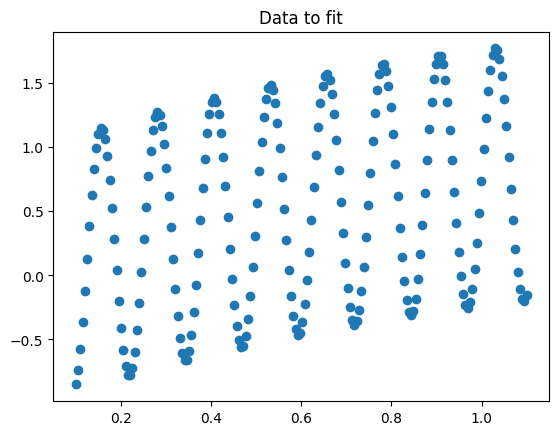

In [12]:
# Model definition 
L = 4
n = 32 

num_samples = 200
# X = jax.random.uniform(jax.random.PRNGKey(0), (num_samples, 1), minval=0, maxval=1)
X = jnp.linspace(0, 1, num_samples).reshape((-1, 1)) + .1
y = jnp.sin(16 * jnp.pi * X) + jnp.tanh(X)

plt.scatter(X, y)
plt.title('Data to fit')
plt.show()
# zeros_to_append = jnp.zeros((num_samples, n-1))

# # Concatenate the original array and the zeros array along axis 1 (columns)
# X = jnp.concatenate((X, zeros_to_append), axis=1)
# y = jnp.concatenate((y, zeros_to_append), axis=1)
# treescope.display((X, y))




## Use conjugate gradient to do precond GD 

We need to change the code a bit to incorporate a preconditioner; change it such that we pass in a operator instead of a matrix. 

In [81]:
@jax.jit
def tree_dot(a, b):
    return jax.tree.reduce(
        lambda x, y: x + y,
        jax.tree.map(lambda x, y: jnp.vdot(x, y), a, b)
    )

@partial(jax.jit, static_argnames=['matvec', 'preconditioner', 'tol', 'max_iter'])
def conjugate_gradient(matvec, b, state, x, tol=1e-5, max_iter=1000, preconditioner=None):
    # If no preconditioner is provided, use the identity operation
    if preconditioner is None:
        preconditioner = lambda tree: tree
    
    def body_fn(carry):
        k, r, p, rsold, i = carry
        Ap = matvec(p)
        alpha = rsold / tree_dot(p, Ap)
        k = jax.tree.map(lambda k, p: k + alpha * p, k, p)
        r = jax.tree.map(lambda r, Ap: r - alpha * Ap, r, Ap)

        
        # Apply the preconditioner to the new residual
        z = preconditioner(r)
        rsnew = tree_dot(r, z) # Now it's r^T z instead of r^T r
        
        beta = rsnew / rsold
        p = jax.tree.map(lambda z_val, p_val: z_val + beta * p_val, z, p) # Update p using z
        return k, r, p, rsnew, i + 1

    def cond_fn(carry):
        _, _, _, rsnew, i = carry
        return jnp.logical_and(jnp.sqrt(rsnew) >= tol, i < max_iter)

    # k = jax.tree.map(jnp.zeros_like, b)  # Initial guess k = 0
    k = b
    r = jax.tree.map(lambda x: x, b)  # Initial residual r = b - A * k (A * k = 0 initially)
    p = jax.tree.map(lambda x: x, r)  # Initial direction p = r
    rsold = tree_dot(r, r)

    init_carry = (k, r, p, rsold, 0)
    k, r, p, rsnew, i = jax.lax.while_loop(cond_fn, body_fn, init_carry)

    return k, (jnp.sqrt(rsnew), i)


In [ ]:
def train_model_precond_cg(X_train, y_train, model, params, learning_rate, num_epochs,
                          lamb=5e-2):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)
    
    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        @jax.jit
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)

        # Conjugate gradient
        # TODO: figure out why 
        # _, f_jvp = jax.linearize(lambda p: 
                                 # state.apply_fn({'params': params}, batch_X), state.params)
        # worked so well? 
        _, f_jvp = jax.linearize(lambda p: 
                                 state.apply_fn({'params': p}, batch_X), 
                                 state.params)
        f_vjp = jax.linear_transpose(f_jvp, state.params)
        
        @jax.jit
        def matvec(k):
            Av = f_vjp(f_jvp(k))[0]
            # Add the regularization term lambda * k
            Av = jax.tree_util.tree_map(lambda a, b: a + lamb * b, Av, k)
            return Av

        grads_cg, lm_data = conjugate_gradient(
            matvec, grads, state, batch_X, max_iter=1000,tol=1e-6
        )

        # We can verify that they're equal by explicitly constructing matrices 
        # Explicitly construct Jacobian 
        # jacobian = jax.jacobian(state.apply_fn, argnums=0)({'params': params}, X)
        # flattened, _ = jax.tree.flatten(jacobian)
        # reshaped_leaves = [leaf.reshape(batch_X.shape[0], -1) for leaf in flattened]
        # aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        # jacobian = aggregated_array.reshape((batch_X.shape[0], -1))
        # jtj = jacobian.T @ jacobian

        # lm_mat = lamb * jnp.eye(jtj.shape[0]) + jtj
        # flattened, back = jax.flatten_util.ravel_pytree(grads)
        # altered = jnp.linalg.solve(lm_mat, flattened) # Solve directly 
        # grads_mat = back(altered) # Convert vector back to PyTree
        
        # l2_norm_diff = jnp.sqrt(sum(jnp.sum((a - b)**2) for a, b in zip(jax.tree_leaves(grads_cg), jax.tree_leaves(grads_mat))))
        # l2_norm_grads_mat = jnp.sqrt(sum(jnp.sum(b**2) for b in jax.tree_leaves(grads_mat)))
        # relative_error = l2_norm_diff / l2_norm_grads_mat
        # jax.debug.print("Diff {relative_error}", relative_error=relative_error)

        # jax.debug.print('Mat {altered}', altered=altered)
        # cg_vec, _ = jax.flatten_util.ravel_pytree(grads_cg)
        # jax.debug.print('cg {altered}', altered=cg_vec)
        # jax.debug.print('cg iter {altered}', altered= lm_data[1])
        
        state = state.apply_gradients(grads=grads_cg)
        return state, loss, lm_data

    losses = []
    cg_stats = {
        'resids': [], 'iters': []
    }

    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss, lm_data = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)
        cg_stats['resids'].append(lm_data[0])
        cg_stats['iters'].append(lm_data[1])

    return state, losses, cg_stats

num_epochs = 10_000

key = jax.random.PRNGKey(0)

model = MLP_1D(num_layers=L, hidden_dim=n)
params = model.init(key, jnp.ones((1, 1)))['params']

# Train the model
# trained_state_precond_cg, precond_losses_cg, cg_stats = train_model_precond_cg(
#     X, y, model, params, learning_rate=1e-2, num_epochs=num_epochs
# )

train_model_precond_cg(
    X, y, model, params, learning_rate=1e-2, num_epochs=num_epochs
)

Starting training for 10000 epochs...


  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
predicted_y = model.apply({'params': trained_state_precond_cg.params}, X)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# First subplot for True vs. Predicted Data
plt.subplot(1, 2, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(X[:, 0], y[:, 0], marker='o', label='True Data', alpha=0.5)
plt.scatter(X[:, 0], predicted_y[:, 0], marker='x', color='red', label='Predicted Data', alpha=0.6)
plt.title('1D Regression Problem: True vs. Predicted Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Second subplot for Training Loss over Epochs
plt.subplot(1, 2, 2)  # 2 rows, 1 column, 2nd subplot
# plt.semilogy(precond_losses, 'x-', label='Precond', markevery=500)
# plt.semilogy(sgd_losses, label='SGD')
plt.semilogy(precond_losses_cg, 'o-', label='CG', markevery=1000)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Show the combined plot
plt.tight_layout()  
plt.show()

In [ ]:
plt.plot(cg_stats['resids'])
plt.show()
plt.plot(cg_stats['iters'])

## Try diagonal preconditioner

In [104]:
def train_model_precond_diag(X_train, y_train, model, params, learning_rate, num_epochs,
                          lamb=5e-2):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)
    
    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        @jax.jit
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)

        # Conjugate gradient
        _, f_jvp = jax.linearize(lambda p: 
                                 state.apply_fn({'params': p}, batch_X), 
                                 state.params)
        f_vjp = jax.linear_transpose(f_jvp, state.params)
        
        @jax.jit
        def matvec(k):
            Av = f_vjp(f_jvp(k))[0]
            # Add the regularization term lambda * k
            Av = jax.tree_util.tree_map(lambda a, b: a + lamb * b, Av, k)
            return Av

        # Explicitly construct Jacobian 
        jacobian = jax.jacobian(state.apply_fn, argnums=0)({'params': state.params}, X)
        flattened, _ = jax.tree.flatten(jacobian)
        reshaped_leaves = [leaf.reshape(batch_X.shape[0], -1) for leaf in flattened]
        aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        jacobian = aggregated_array.reshape((batch_X.shape[0], -1))
        jtj = jacobian.T @ jacobian

        matrix = lamb * jnp.eye(jtj.shape[0]) + jtj
        eigs = jnp.linalg.eigvalsh(matrix)
        
        jax.debug.print("Non-preconditioned condition number: \t{cond:.2e}", cond=jnp.max(eigs) / jnp.min(eigs))


        # precond = jnp.diag(1 / jnp.diag(matrix)) @ matrix 
        precond = jnp.diag(jnp.sqrt(1 / jnp.diag(matrix))) @ matrix @ jnp.diag(jnp.sqrt(1 / jnp.diag(matrix)))
        eigs = jnp.linalg.eigvalsh(precond)
        
        jax.debug.print("Preconditioned condition number: \t{cond:.2e}", cond=jnp.max(eigs) / jnp.min(eigs))

        
        # # jax.debug.print('diag: {diag}', diag=jtj[0:10, 0:10])
        # diag_JTJ = jnp.sum(jacobian**2, axis=0)  # Sum of squares along rows (column-wise sum)
        # jax.debug.print('diag: {diag}', diag=diag_JTJ)

        # Compute column norms
        # col_norms =jnp.sqrt(jnp.sum(jacobian**2, axis=0))
        
        # # Compute the inverse of the squared column norms
        # inv_col_norms_squared = 1.0 / (col_norms**2)

        
        @jax.jit
        def precond(k):
            # flat, back = jax.flatten_util.ravel_pytree(k)
            # return back(flat / (1 + diag_JTJ))
            return k
            
        # jax.debug.print('{diag_JTJ}', diag_JTJ=len(diag_JTJ))

        grads_cg, lm_data = conjugate_gradient(
            matvec, grads, state, batch_X, max_iter=5,tol=1e-8, preconditioner=precond
        )

        
        state = state.apply_gradients(grads=grads_cg)
        return state, loss, lm_data

    losses = []
    cg_stats = {
        'resids': [], 'iters': []
    }

    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss, lm_data = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)
        cg_stats['resids'].append(lm_data[0])
        cg_stats['iters'].append(lm_data[1])

    return state, losses, cg_stats

num_epochs = 10

key = jax.random.PRNGKey(0)

model = MLP_1D(num_layers=L, hidden_dim=n)
params = model.init(key, jnp.ones((1, 1)))['params']

# Train the model
trained_state_precond_diag, precond_losses_diag, diag_stats = train_model_precond_diag(
    X, y, model, params, learning_rate=1e-2, num_epochs=num_epochs
)

Starting training for 10 epochs...


  0%|          | 0/10 [00:00<?, ?it/s]

Non-preconditioned condition number: 	1.19e+05
Preconditioned condition number: 	7.29e+06
Non-preconditioned condition number: 	1.22e+05
Preconditioned condition number: 	7.34e+06
Non-preconditioned condition number: 	1.23e+05
Preconditioned condition number: 	7.35e+06
Non-preconditioned condition number: 	1.23e+05
Preconditioned condition number: 	7.36e+06
Non-preconditioned condition number: 	1.24e+05
Preconditioned condition number: 	7.36e+06
Non-preconditioned condition number: 	1.24e+05
Preconditioned condition number: 	7.37e+06
Non-preconditioned condition number: 	1.24e+05
Preconditioned condition number: 	7.37e+06
Non-preconditioned condition number: 	1.24e+05
Preconditioned condition number: 	7.37e+06
Non-preconditioned condition number: 	1.24e+05
Preconditioned condition number: 	7.38e+06
Non-preconditioned condition number: 	1.24e+05
Preconditioned condition number: 	7.38e+06


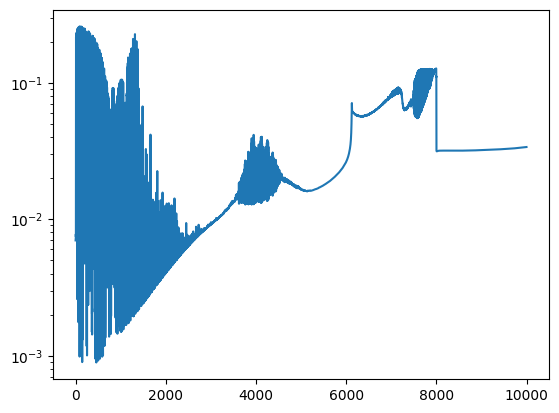

[<matplotlib.lines.Line2D at 0x7fa38c63d1d0>]

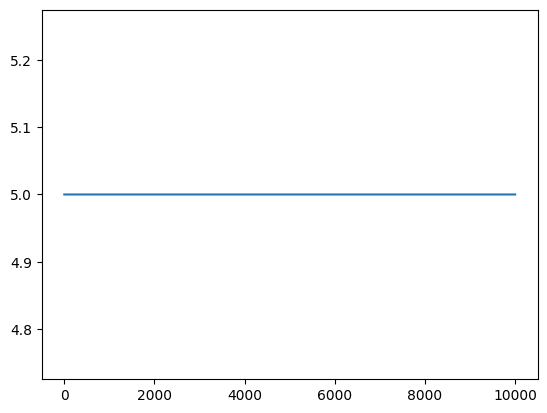

In [95]:
plt.semilogy(diag_stats['resids'])
plt.show()
plt.plot(diag_stats['iters'])

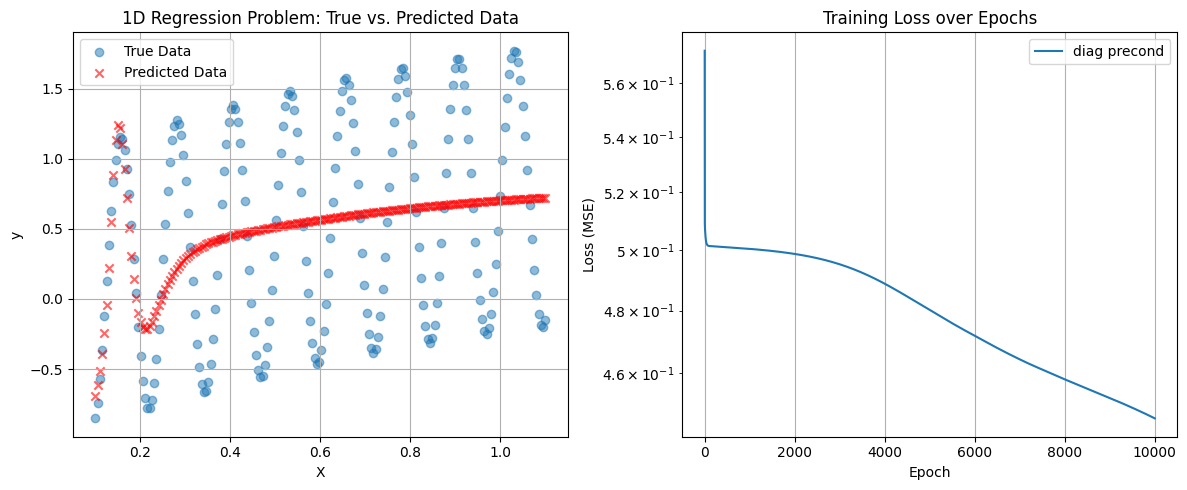

In [96]:
predicted_y = model.apply({'params': trained_state_precond_diag.params}, X)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# First subplot for True vs. Predicted Data
plt.subplot(1, 2, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(X[:, 0], y[:, 0], marker='o', label='True Data', alpha=0.5)
plt.scatter(X[:, 0], predicted_y[:, 0], marker='x', color='red', label='Predicted Data', alpha=0.6)
plt.title('1D Regression Problem: True vs. Predicted Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Second subplot for Training Loss over Epochs
plt.subplot(1, 2, 2)  # 2 rows, 1 column, 2nd subplot
# plt.semilogy(precond_losses, 'x-', label='Precond', markevery=500)
# plt.semilogy(sgd_losses, label='SGD')
plt.semilogy(precond_losses_diag, label='diag precond')
# plt.semilogy(precond_losses_cg, 'o-', label='CG', markevery=1000)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Show the combined plot
plt.tight_layout()  
plt.show()

Basically, diagonal preconditioning does not work for Gauss-Newton matrices. The obvious next step is to just look at block Jacobi of each layer. 

What does this entail? 

1. Let's just look at the condition number for the first few iterations first. It seems that that's an easier problem so if it doesn't work there, why should it work later?
2. For each layer, we need to find the number of parameters $p_i$
3. Let's do the dumb construction, using the list of $p_i$, we then go block by block in the full $J^TJ + \lambda I$, take it's inverse, then put it in the matrix.



In [136]:
def train_model_precond_block(X_train, y_train, model, params, learning_rate, num_epochs,
                          lamb=5e-2, block_sizes = None):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)
    
    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        @jax.jit
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)

        # Conjugate gradient
        _, f_jvp = jax.linearize(lambda p: 
                                 state.apply_fn({'params': p}, batch_X), 
                                 state.params)
        f_vjp = jax.linear_transpose(f_jvp, state.params)
        
        @jax.jit
        def matvec(k):
            Av = f_vjp(f_jvp(k))[0]
            # Add the regularization term lambda * k
            Av = jax.tree_util.tree_map(lambda a, b: a + lamb * b, Av, k)
            return Av

        # Explicitly construct Jacobian 
        jacobian = jax.jacobian(state.apply_fn, argnums=0)({'params': state.params}, X)
        flattened, _ = jax.tree.flatten(jacobian)
        reshaped_leaves = [leaf.reshape(batch_X.shape[0], -1) for leaf in flattened]
        aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        jacobian = aggregated_array.reshape((batch_X.shape[0], -1))
        jtj = jacobian.T @ jacobian

        matrix = lamb * jnp.eye(jtj.shape[0]) + jtj
        eigs = jnp.linalg.eigvalsh(matrix)
        
        jax.debug.print("Non-preconditioned condition number: \t{cond:.2e}", cond=jnp.max(eigs) / jnp.min(eigs))

        block_diag = jnp.zeros_like(jtj)

        index = 0
        blocks = []
        for block_size in block_sizes:
            blocks.append(jnp.linalg.inv(matrix[index:index + block_size, index:index + block_size]))
        precond_matrix = jax.scipy.linalg.block_diag(*blocks).astype('float32')
        
        # jax.debug.print('type {dtype}', dtype=precond_matrix.dtype)
        # eigs = jnp.linalg.eigvalsh(precond @ matrix)
        # jax.debug.print("Preconditioned condition number: \t{cond:.2e}", cond=jnp.max(eigs) / jnp.min(eigs))
        
        @jax.jit
        def precond(k):
            flat, back = jax.flatten_util.ravel_pytree(k)
            return back(precond_matrix @ flat)
            # return k
            
        # jax.debug.print('{diag_JTJ}', diag_JTJ=len(diag_JTJ))

        grads_cg, lm_data = conjugate_gradient(
            matvec, grads, state, batch_X, max_iter=100,tol=1e-8, preconditioner=precond
        )
        jax.debug.print('iters {dtype}', dtype=lm_data[1])

        
        state = state.apply_gradients(grads=grads_cg)
        return state, loss, lm_data

    losses = []
    cg_stats = {
        'resids': [], 'iters': []
    }

    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss, lm_data = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)
        cg_stats['resids'].append(lm_data[0])
        cg_stats['iters'].append(lm_data[1])

    return state, losses, cg_stats

num_epochs = 10

key = jax.random.PRNGKey(0)

model = MLP_1D(num_layers=L, hidden_dim=n)
params = model.init(key, jnp.ones((1, 1)))['params']

param_list = []
for name, layer_params in params.items(): 
    param_list.append(sum(param.size for param in layer_params.values()))
assert sum(param.size for param in jax.tree_util.tree_leaves(params)) == sum(param_list)

# Train the model
train_model_precond_block(
    X, y, model, params, learning_rate=1e-2, num_epochs=num_epochs, block_sizes=param_list
)

Starting training for 10 epochs...


  0%|          | 0/10 [00:00<?, ?it/s]

iters 100
Non-preconditioned condition number: 	1.19e+05
iters 100
Non-preconditioned condition number: 	1.22e+05
iters 100
Non-preconditioned condition number: 	1.23e+05
iters 100
Non-preconditioned condition number: 	1.23e+05
iters 100
Non-preconditioned condition number: 	1.24e+05
iters 100
Non-preconditioned condition number: 	1.24e+05
iters 100
Non-preconditioned condition number: 	1.24e+05
iters 100
Non-preconditioned condition number: 	1.24e+05
iters 100
Non-preconditioned condition number: 	1.24e+05
iters 100
Non-preconditioned condition number: 	1.24e+05


(TrainState(step=Array(10, dtype=int64, weak_type=True), apply_fn=<bound method Module.apply of MLP_1D(
     # attributes
     num_layers = 4
     hidden_dim = 32
 )>, params={'Dense_0': {'bias': Array([-1.9388752e-03, -3.4284571e-04,  7.0894366e-06, -3.6260358e-04,
         1.1440217e-03, -1.9000783e-03, -2.2568782e-03, -1.0951533e-03,
        -2.2107399e-04, -2.8331752e-03,  1.3877047e-03, -1.4225492e-03,
        -4.6340137e-05, -1.1659008e-03,  2.3230028e-03,  5.1942468e-05,
         8.3841215e-04,  2.6335777e-04,  9.1742491e-04,  1.0029689e-03,
         5.6517578e-04,  7.6942897e-04, -2.0096835e-03, -2.3017959e-04,
         2.7232216e-04, -5.0587521e-04,  3.7212529e-05,  3.9285881e-04,
         1.0879087e-03,  1.5225551e-06, -1.6157843e-04, -1.3353003e-03],      dtype=float32), 'kernel': Array([[-2.1910546 ,  1.2656642 , -1.9874927 , -1.4022421 ,  1.4916759 ,
          1.9017433 ,  1.6465205 , -0.08539611,  0.7441489 ,  1.2987659 ,
         -2.2850404 ,  1.4054728 , -1.1952592 ,  0.8880074 ,  1.8411099 ,
         -0.49079412, -2.0735655 , -1.9361341 , -1.2019405 , -0.05824625,
         -0.6023646 , -1.0707685 , -2.4031377 , -0.93564737, -1.7652396 ,
         -1.0452931 ,  0.9455905 , -1.2343707 ,  1.8941737 ,  1.8444011 ,
          2.221354  , -2.058877  ]], dtype=float32)}, 'Dense_1': {'bias': Array([-6.6276616e-04,  4.9383636e-04,  3.3170788e-04,  9.9074224e-04,
         1.6772318e-04,  2.3765367e-04, -3.5026338e-04, -5.4746668e-04,
         6.0879748e-04,  3.1719595e-04, -3.1036907e-04,  7.6697010e-04,
        -4.8188333e-04,  3.8809906e-04,  1.1406207e-04,  3.2881778e-04,
        -8.8384131e-04, -1.3607498e-03,  2.3414061e-05,  1.8928869e-04,
         2.4392884e-04,  1.2104491e-04, -5.3993880e-04,  3.4597341e-04,
         7.8390812e-04,  6.9349061e-04, -8.1077398e-04,  4.6660472e-04,
        -1.2258224e-03,  2.5975794e-04,  1.4329693e-04,  7.8242150e-04],      dtype=float32), 'kernel': Array([[ 7.9030474e-04,  9.8121986e-02,  5.7397820e-02, ...,
         -3.3265918e-01,  1.8158172e-01, -1.4896464e-01],
        [ 3.2999873e-01, -3.2732713e-01,  3.9757779e-01, ...,
         -8.3563961e-02,  3.1397045e-01,  1.8893433e-01],
        [ 1.3568610e-01, -4.2050007e-01, -1.5828624e-02, ...,
          8.5133143e-02, -2.9775793e-02, -1.5604296e-01],
        ...,
        [ 2.1341485e-01, -1.2078871e-01,  1.1227922e-01, ...,
          1.1144814e-01,  1.7719871e-01,  1.2626383e-01],
        [ 2.0217486e-01, -2.0070201e-01, -4.0926969e-01, ...,
          2.7715036e-01,  2.1450855e-01, -3.4893927e-01],
        [ 1.2116002e-01,  1.8268754e-01,  2.3617411e-04, ...,
          3.3341140e-01,  3.9888379e-01, -2.1891513e-01]], dtype=float32)}, 'Dense_2': {'bias': Array([ 1.9891701e-04, -2.5083646e-04, -1.8310506e-04,  6.0393929e-04,
        -7.5278315e-04,  4.4561666e-04,  7.0551992e-04, -1.3861954e-03,
        -9.2552509e-06, -1.8756574e-03,  6.6865882e-04, -2.1817110e-04,
         1.6114490e-04, -4.9638882e-04,  6.9128966e-04,  4.3015665e-04,
        -1.3202225e-04, -1.6142285e-04,  1.6035198e-04, -1.0245127e-03,
         1.8568625e-04,  6.5168901e-04,  4.5722804e-04, -7.5301396e-05,
         3.1882861e-05,  1.1309383e-04,  2.8482461e-04,  3.2320590e-05,
        -3.4256802e-05, -3.6083884e-04,  9.9588062e-05, -4.7958572e-05],      dtype=float32), 'kernel': Array([[ 0.37759084, -0.11372449,  0.13347222, ...,  0.36755916,
          0.05172423, -0.18109024],
        [-0.35794818, -0.20028676, -0.16107473, ...,  0.20482366,
          0.32188308, -0.40203163],
        [-0.03241659, -0.1293029 ,  0.16588175, ..., -0.2910138 ,
          0.1671777 ,  0.05673832],
        ...,
        [-0.17558923, -0.27233362,  0.19588333, ..., -0.42240015,
         -0.27870786, -0.05507033],
        [ 0.04854003, -0.39888644, -0.12134308, ..., -0.2782402 ,
          0.30377716,  0.07884052],
        [-0.01937385,  0.09671166, -0.06478683, ..., -0.131948  ,
          0.33406487,  0.14470066]], dtype=float32)}, 'Dense_3': {'bias': Array([ 6.2638312e-04, -1.8349601e

Ugh, these matrices are really bad at being preconditioned!!! 

Let's do a more compreshensive study tomorrow; 

Things to consider: 

1. High/medium/low frequency data fitting
2. Same model size, differing layers/width
3. Skip/residual connections versus none
4. Dynamics as we train and it's effect with learning rate?
6. How does regularization effect the condition number? 



dumb idea: use progressively better initial conditions using \lambda large, versus lambda small